In [1]:
from IPython.display import clear_output
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from LatentEvolution.zapbench_data import load_sparse_activity
from LatentEvolution.zapbench_config import CONDITIONS, DataConfig, DataSplit
from LatentEvolution.mlp import MLP, MLPParams

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu")
print(f"using device: {device}")
torch.set_float32_matmul_precision('high')


using device: cuda


/workspace/.conda_envs/neural-graph-linux/lib/python3.12/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


## load data

In [2]:
BIN_SIZE_MS = 100.0  # 100ms bins


In [3]:
# load all training conditions
data_cfg = DataConfig(bin_size_ms=BIN_SIZE_MS)
# data_cfg = DataConfig(
#     traces_path="/Users/kumarv/zapbench-data/traces",
#     ephys_path="/Users/kumarv/zapbench-data/ephys.zarr",
#     bin_size_ms=BIN_SIZE_MS
# )
data_split = DataSplit()

# get train and val ranges
train_ranges = data_split.get_ranges("train")
val_ranges = data_split.get_ranges("val")

print("training conditions:")
for name, start, end in train_ranges:
    print(f"  {name}: bins {start}-{end} ({end-start} frames)")

print("\nvalidation conditions:")
for name, start, end in val_ranges:
    print(f"  {name}: bins {start}-{end} ({end-start} frames)")

training conditions:
  gain: bins 1-454 (453 frames)
  dots: bins 650-1890 (1240 frames)
  flash: bins 2423-2881 (458 frames)
  turning: bins 3736-4653 (917 frames)
  position: bins 5048-5460 (412 frames)
  open_loop: bins 5639-6327 (688 frames)
  rotation: bins 6624-7082 (458 frames)
  dark: bins 7280-7698 (418 frames)

validation conditions:
  gain: bins 454-519 (65 frames)
  dots: bins 1890-2067 (177 frames)
  flash: bins 2881-2946 (65 frames)
  turning: bins 4653-4784 (131 frames)
  position: bins 5460-5519 (59 frames)
  open_loop: bins 6327-6425 (98 frames)
  rotation: bins 7082-7147 (65 frames)
  dark: bins 7698-7758 (60 frames)


In [4]:
# load data for a list of ranges, concatenate along time
def load_ranges(ranges, bin_size_ms):
    """load and concatenate data from multiple ranges.

    returns: obs_times, obs_vals, counts, total_bins, range_boundaries
    """
    all_obs_times = []
    all_obs_vals = []
    range_boundaries = [0]
    total_bins = 0

    for name, start, end in ranges:
        # load this range
        obs_times, obs_vals, counts, num_bins = load_sparse_activity(
            traces_path=data_cfg.traces_path,
            ephys_path=data_cfg.ephys_path,
            bin_size_ms=bin_size_ms,
            time_slice=slice(start, end),
        )

        # offset times by current total
        obs_times_offset = obs_times + total_bins
        all_obs_times.append(obs_times_offset)
        all_obs_vals.append(obs_vals)

        total_bins += num_bins
        range_boundaries.append(total_bins)
        print(f"  loaded {name}: {num_bins} bins, total now {total_bins}")

    # concatenate along observation dimension (K)
    obs_times_cat = torch.cat(all_obs_times, dim=1)
    obs_vals_cat = torch.cat(all_obs_vals, dim=1)
    counts_cat = torch.tensor([obs_times_cat.shape[1]] * obs_times_cat.shape[0])

    return obs_times_cat, obs_vals_cat, counts_cat, total_bins, range_boundaries

print("loading training data...")
train_obs_times, train_obs_vals, train_counts, train_T, train_boundaries = load_ranges(
    train_ranges, BIN_SIZE_MS
)
N_full = train_obs_times.shape[0]
print(f"\ntotal: {N_full} neurons, {train_T} bins, {train_obs_times.shape[1]} obs per neuron")

loading training data...
  loaded gain: 4140 bins, total now 4140
  loaded dots: 11333 bins, total now 15473
  loaded flash: 4186 bins, total now 19659
  loaded turning: 8381 bins, total now 28040
  loaded position: 3766 bins, total now 31806
  loaded open_loop: 6288 bins, total now 38094
  loaded rotation: 4186 bins, total now 42280
  loaded dark: 3820 bins, total now 46100

total: 71721 neurons, 46100 bins, 5044 obs per neuron


In [5]:
condition_index = 0
bin_low = train_boundaries[condition_index]
bin_high = train_boundaries[condition_index+1]

obs_vals = train_obs_vals[:, bin_low:bin_high]
obs_times = train_obs_times[:, bin_low:bin_high]

In [6]:
obs_times.shape

torch.Size([71721, 4140])

low  CV neurons  (<p10):    7,172
med  CV neurons  (p40-p60): 14,345
high CV neurons  (>=p99):   718


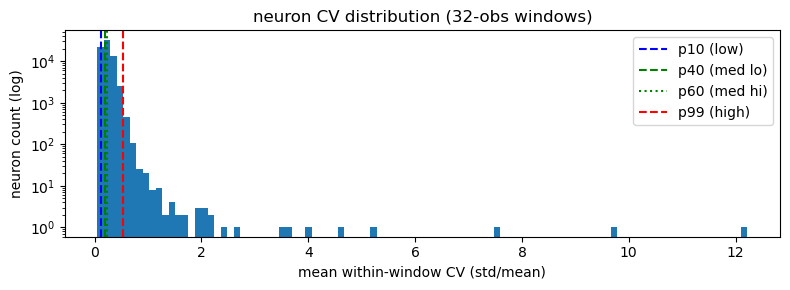

In [7]:
# compute per-neuron CV (std/mean) within 32-observation windows
WINDOW = 32

N, K_obs = obs_vals.shape
num_windows = K_obs // WINDOW

# reshape into (N, num_windows, WINDOW)
obs_w = obs_vals[:, :num_windows * WINDOW].reshape(N, num_windows, WINDOW)

mean_w = obs_w.mean(dim=2)          # (N, num_windows)
std_w  = obs_w.std(dim=2)           # (N, num_windows)
cv_w   = std_w / mean_w
cv_w[mean_w <= 0] = float('nan')

neuron_cv = torch.nanmean(cv_w, dim=1)  # (N,)

valid_cv = neuron_cv[torch.isfinite(neuron_cv)]
p_low    = torch.quantile(valid_cv, 0.10)
p_med_lo = torch.quantile(valid_cv, 0.40)
p_med_hi = torch.quantile(valid_cv, 0.60)
p_high   = torch.quantile(valid_cv, 0.99)

low_neurons  = torch.where(neuron_cv < p_low)[0]
med_neurons  = torch.where((neuron_cv >= p_med_lo) & (neuron_cv <= p_med_hi))[0]
high_neurons = torch.where(neuron_cv >= p_high)[0]

print(f"low  CV neurons  (<p10):    {len(low_neurons):,}")
print(f"med  CV neurons  (p40-p60): {len(med_neurons):,}")
print(f"high CV neurons  (>=p99):   {len(high_neurons):,}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(valid_cv.cpu().numpy(), bins=100, log=True)
ax.axvline(p_low.item(),    color='blue',  linestyle='--', label='p10 (low)')
ax.axvline(p_med_lo.item(), color='green', linestyle='--', label='p40 (med lo)')
ax.axvline(p_med_hi.item(), color='green', linestyle=':',  label='p60 (med hi)')
ax.axvline(p_high.item(),   color='red',   linestyle='--', label='p99 (high)')
ax.set_xlabel('mean within-window CV (std/mean)')
ax.set_ylabel('neuron count (log)')
ax.set_title(f'neuron CV distribution ({WINDOW}-obs windows)')
ax.legend()
plt.tight_layout()
plt.show()


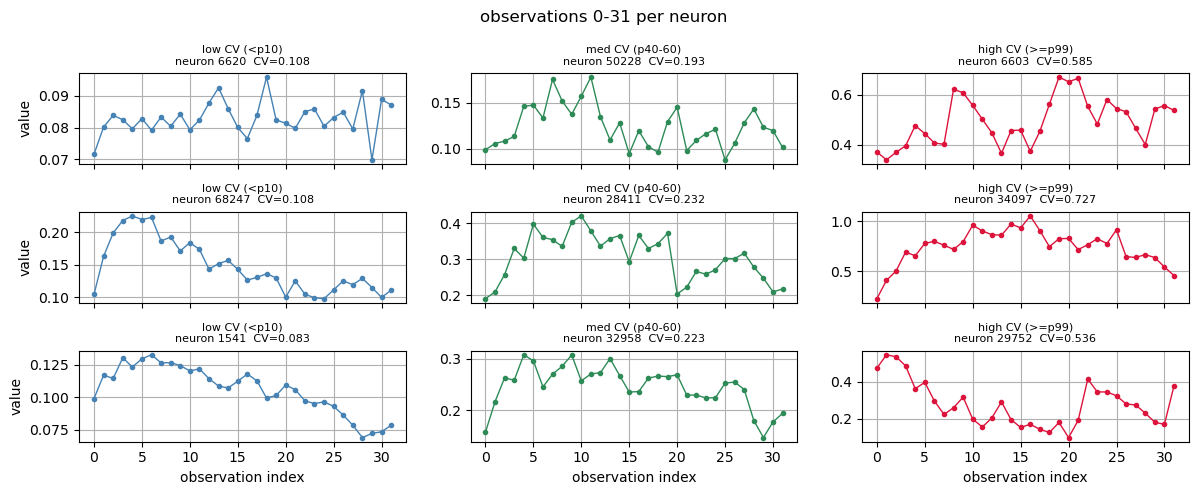

In [8]:
# plot 3 random neurons from each CV category, 32 consecutive observations
OBS_START = 0
N_PICK = 3
SEED = 42

rng = torch.Generator()
rng.manual_seed(SEED)

sample_low  = low_neurons[torch.randperm(len(low_neurons),  generator=rng)[:N_PICK]]
sample_med  = med_neurons[torch.randperm(len(med_neurons),  generator=rng)[:N_PICK]]
sample_high = high_neurons[torch.randperm(len(high_neurons), generator=rng)[:N_PICK]]

fig, axes = plt.subplots(N_PICK, 3, figsize=(12, 5), sharey=False, sharex=True)

for col, (label, neurons, color) in enumerate([
    ('low CV (<p10)',   sample_low,  'steelblue'),
    ('med CV (p40-60)', sample_med,  'seagreen'),
    ('high CV (>=p99)', sample_high, 'crimson'),
]):
    for row, nid in enumerate(neurons):
        ax = axes[row, col]
        vals = obs_vals[nid, OBS_START:OBS_START + 32].cpu()
        ax.plot(vals.numpy(), color=color, marker='o', markersize=3, linewidth=1)
        ax.set_title(f'{label}\nneuron {nid.item()}  CV={neuron_cv[nid].item():.3f}', fontsize=8)
        if row == N_PICK - 1:
            ax.set_xlabel('observation index')
        if col == 0:
            ax.set_ylabel('value')
        ax.grid(True)

plt.suptitle(f'observations {OBS_START}-{OBS_START+31} per neuron')
plt.tight_layout()
plt.show()


## Train with z bank

In [76]:
# --- hyperparameters ---
L_DIM = 64

N = obs_vals.shape[0]

# --- evolver: z[t] -> z[t+1] ---
evolver = MLP(MLPParams(
    num_input_dims=L_DIM,
    num_output_dims=L_DIM,
    num_hidden_layers=1,
    num_hidden_units=L_DIM,
    activation='Tanh',
    use_batch_norm=False,
)).to(device)

# --- linear decoder: random initialization ---
# W_dec: (N, L_DIM), b_dec: (N,)
W_dec = nn.Parameter(torch.randn(N, L_DIM, device=device) * 0.01)
b_dec = nn.Parameter(torch.zeros(N, device=device))

print(f"W_dec shape: {W_dec.shape}, b_dec shape: {b_dec.shape}")

def get_window(k_start):
    """extract a WINDOW-obs window.

    returns:
        w_vals:   (N, WINDOW)  observed values
        obs_idx:  (N, WINDOW)  indices into the T_window rollout where each
                               observation falls, i.e. x_hat[n, obs_idx[n, k]]
                               should match w_vals[n, k]
        T_window: int          number of evolver steps needed
    """
    w_vals  = obs_vals[:, k_start:k_start + WINDOW]   # (N, WINDOW)
    w_times = obs_times[:, k_start:k_start + WINDOW]  # (N, WINDOW)
    t_min   = int(w_times.min().item())
    t_max   = int(w_times.max().item())
    T_window = t_max - t_min + 1
    obs_idx  = (w_times - t_min).long()               # (N, WINDOW), in [0, T_window)
    return w_vals, obs_idx, T_window

def rollout(z0, T):
    """evolve z0 for T steps: returns z of shape (T, L_DIM)."""
    zs = [None] * T  # preallocate list
    zs[0] = z0
    z = z0
    for t in range(1, T):
        z = z + evolver(z.unsqueeze(0)).squeeze(0)
        zs[t] = z
    return torch.stack(zs, dim=0)

def decode(z):
    """linear decode: z (T, L_DIM) -> x_hat (N, T)."""
    return (z @ W_dec.T + b_dec).T  # (N, T)


def plot_rollout(k_start=0, title=''):
    """roll out from z_bank[t0] using evolver, decode, compare to raw (phase 2 quality)."""
    w_vals_p  = obs_vals[:, k_start:k_start + WINDOW]          # (N, WINDOW)
    w_times_p = obs_times[:, k_start:k_start + WINDOW]         # (N, WINDOW)
    t0       = int(w_times_p.min().item())
    T_window = int(w_times_p.max().item()) - t0 + 1
    obs_idx  = (w_times_p - t0).long()                         # (N, WINDOW)

    with torch.no_grad():
        z0_t = z_bank[t0]                                                  # (L_DIM,)
        z    = rollout(z0_t, T_window)                         # (T_window, L_DIM)
        x_hat = decode(z)                                      # (N, T_window)
        x_pred = x_hat[torch.arange(N, device=device).unsqueeze(1),
                        obs_idx.to(device)]                    # (N, WINDOW)

    fig, axes = plt.subplots(N_PICK, 3, figsize=(12, 5), sharey=False)
    for col, (label, neurons, color) in enumerate([
        ('low CV (<p10)',   sample_low,  'steelblue'),
        ('med CV (p40-60)', sample_med,  'seagreen'),
        ('high CV (>=p99)', sample_high, 'crimson'),
    ]):
        for row, nid in enumerate(neurons):
            ax = axes[row, col]
            raw  = w_vals_p[nid].cpu().numpy()
            pred = x_pred[nid].cpu().numpy()
            ax.plot(raw,  color=color,   marker='o', markersize=3, linewidth=1, label='raw')
            ax.plot(pred, color='black', marker='x', markersize=3, linewidth=1,
                    linestyle='--', label='rollout')
            ymin, ymax = raw.min(), raw.max()
            margin = (ymax - ymin) * 0.1 or 0.1
            ax.set_ylim(ymin - margin, ymax + margin)
            ax.set_title(f'{label}\nneuron {nid.item()}  CV={neuron_cv[nid].item():.3f}', fontsize=8)
            if row == N_PICK - 1:
                ax.set_xlabel('observation index')
            if col == 0:
                ax.set_ylabel('value')
            if row == 0 and col == 0:
                ax.legend(fontsize=7)
    plt.suptitle(title or f'evolver rollout from t0={t0}  (window k_start={k_start})')
    plt.tight_layout()
    plt.show()

W_dec shape: torch.Size([71721, 64]), b_dec shape: torch.Size([71721])


In [77]:

def plot_reconstruction(k_start=0, title='', window=WINDOW):
    """plot z_bank decoded reconstruction vs raw (phase 1 quality)."""
    w_vals_p  = obs_vals[:, k_start:k_start + window]          # (N, WINDOW)
    w_times_p = obs_times[:, k_start:k_start + window]         # (N, WINDOW)
    with torch.no_grad():
        z_at_obs = z_bank[w_times_p.long().to(device)]          # (N, WINDOW, L_DIM)
        x_pred   = (z_at_obs * W_dec.unsqueeze(1)).sum(-1) + b_dec.unsqueeze(1)  # (N, WINDOW)

    fig, axes = plt.subplots(N_PICK, 3, figsize=(12, 5), sharey=False)
    for col, (label, neurons, color) in enumerate([
        ('low CV (<p10)',   sample_low,  'steelblue'),
        ('med CV (p40-60)', sample_med,  'seagreen'),
        ('high CV (>=p99)', sample_high, 'crimson'),
    ]):
        for row, nid in enumerate(neurons):
            ax = axes[row, col]
            raw  = w_vals_p[nid].cpu().numpy()
            pred = x_pred[nid].cpu().numpy()
            ax.plot(raw,  color=color,   marker='o', markersize=3, linewidth=1, label='raw')
            ax.plot(pred, color='black', marker='x', markersize=3, linewidth=1,
                    linestyle='--', label='recon')
            ymin, ymax = raw.min(), raw.max()
            margin = (ymax - ymin) * 0.1 or 0.1
            ax.set_ylim(ymin - margin, ymax + margin)
            ax.set_title(f'{label}\nneuron {nid.item()}  CV={neuron_cv[nid].item():.3f}', fontsize=8)
            if row == N_PICK - 1:
                ax.set_xlabel('observation index')
            if col == 0:
                ax.set_ylabel('value')
            if row == 0 and col == 0:
                ax.legend(fontsize=7)
    plt.suptitle(title or f'reconstruction from z_bank  (window k_start={k_start})')
    plt.tight_layout()
    plt.show()


In [78]:
# --- two-phase training ---
LR_PHASE1  = 1e-4
LR_PHASE2  = 1e-3
ROLLOUT    = 100
BATCH_SIZE = 32   # for phase 2


TV_WEIGHT  = 0.1  # smoothness regularization on z_bank
T = int(obs_times.max().item()) + 1

# z_bank: one latent per time bin
z_bank = nn.Parameter(torch.zeros(T, L_DIM, device=device))
nn.init.normal_(z_bank, std=0.01)

# init evolver output to ~0: zero last linear layer
with torch.no_grad():
    last_linear = [m for m in evolver.modules() if isinstance(m, nn.Linear)][-1]
    last_linear.weight.zero_()
    last_linear.bias.zero_()

# compiled functions for speedup
@torch.compile(mode="reduce-overhead")
def phase1_forward(z_bank, w_times_k, W_dec, b_dec):
    """phase 1: index z_bank and decode."""
    z_at_obs = z_bank[w_times_k]
    x_pred = (z_at_obs * W_dec.unsqueeze(1)).sum(-1) + b_dec.unsqueeze(1)
    return x_pred

@torch.compile(mode="reduce-overhead")
def batched_rollout(z_start, steps):
    """phase 2: batched rollout through evolver."""
    zs = [z_start]
    z = z_start
    for _ in range(steps - 1):
        z = z + evolver(z)
        zs.append(z)
    return torch.stack(zs, dim=0)

In [79]:
# warmup compiled functions
import time

print("warming up compiled functions...")

# dummy inputs matching real shapes
dummy_times = torch.randint(0, T, (N, WINDOW), device=device)
dummy_z_start = torch.randn(BATCH_SIZE, L_DIM, device=device)

# phase1_forward warmup
t0 = time.perf_counter()
_ = phase1_forward(z_bank, dummy_times, W_dec, b_dec)
torch.cuda.synchronize()
print(f"  phase1_forward compiled in {time.perf_counter() - t0:.1f}s")

# batched_rollout warmup
t0 = time.perf_counter()
_ = batched_rollout(dummy_z_start, ROLLOUT)
torch.cuda.synchronize()
print(f"  batched_rollout compiled in {time.perf_counter() - t0:.1f}s")

print("warmup done")

warming up compiled functions...
  phase1_forward compiled in 0.1s
  batched_rollout compiled in 2.6s
warmup done


In [72]:
N_PHASE1_EPOCHS = 200
N_PHASE2_EPOCHS = 10


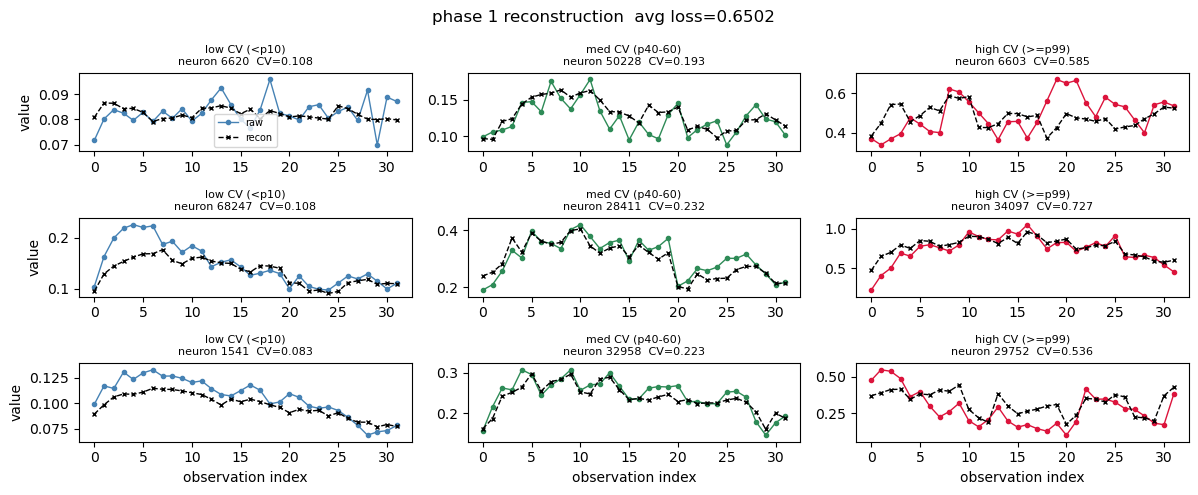

  epoch 197/200  avg loss=0.6472
  epoch 198/200  avg loss=0.6470
  epoch 199/200  avg loss=0.6469
  epoch 200/200  avg loss=0.6469
phase 1 done  avg loss=0.6501


In [32]:

num_windows_per_epoch = obs_vals.shape[1] // WINDOW

# ── phase 1: reconstruct obs_vals from z_bank ──────────────────────────────
print("phase 1: reconstruction")
opt1 = torch.optim.Adam(
    [z_bank, W_dec, b_dec], lr=LR_PHASE1
)
p1_losses = []
for epoch in range(N_PHASE1_EPOCHS):
    for k in range(num_windows_per_epoch):
        w_vals_k  = obs_vals[:, k * WINDOW:(k + 1) * WINDOW].to(device)         # (N, WINDOW)
        w_times_k = obs_times[:, k * WINDOW:(k + 1) * WINDOW].long().to(device)  # (N, WINDOW)

        x_pred = phase1_forward(z_bank, w_times_k, W_dec, b_dec)                 # (N, WINDOW)

        # normalize by per-neuron within-window std; skip constant neurons
        std_k = w_vals_k.std(dim=1)                                              # (N,)
        valid = std_k > 1e-3
        if not valid.any():
            continue
        recon_loss = (((x_pred[valid] - w_vals_k[valid]) / std_k[valid].unsqueeze(1)) ** 2).mean()

        # tv regularization: penalize large jumps between adjacent time bins
        tv_loss = ((z_bank[1:] - z_bank[:-1]) ** 2).mean()

        loss = recon_loss #+ TV_WEIGHT * tv_loss

        opt1.zero_grad()
        loss.backward()
        opt1.step()
        p1_losses.append(recon_loss.item())


    avg = sum(p1_losses[-num_windows_per_epoch:]) / max(len(p1_losses[-num_windows_per_epoch:]), 1)

    print(f"  epoch {epoch+1}/{N_PHASE1_EPOCHS}  avg loss={avg:.4f}")
    if epoch % 5 == 0:
        clear_output(wait=True)
        plot_reconstruction(title=f'phase 1 reconstruction  avg loss={sum(p1_losses)/len(p1_losses):.4f}')


print(f"phase 1 done  avg loss={sum(p1_losses)/len(p1_losses):.4f}")

In [73]:
N_PHASE2_EPOCHS = 100

In [80]:

# --- EM training loop ---
print("phase 2: EM-style evolver training")
LR_PHASE2_EM = 1e-3
N_PHASE2_EM_EPOCHS = 20
WINDOW_EM = WINDOW  # use same window size

# # reinitialize evolver to identity (zero output)
# with torch.no_grad():
#     last_linear = [m for m in evolver.modules() if isinstance(m, nn.Linear)][-1]
#     last_linear.weight.zero_()
#     last_linear.bias.zero_()

opt_em = torch.optim.Adam(
    [W_dec, b_dec] + list(evolver.parameters()),
    lr=LR_PHASE2_EM
)

phase 2: EM-style evolver training


  epoch 13/20  avg loss=2.4491


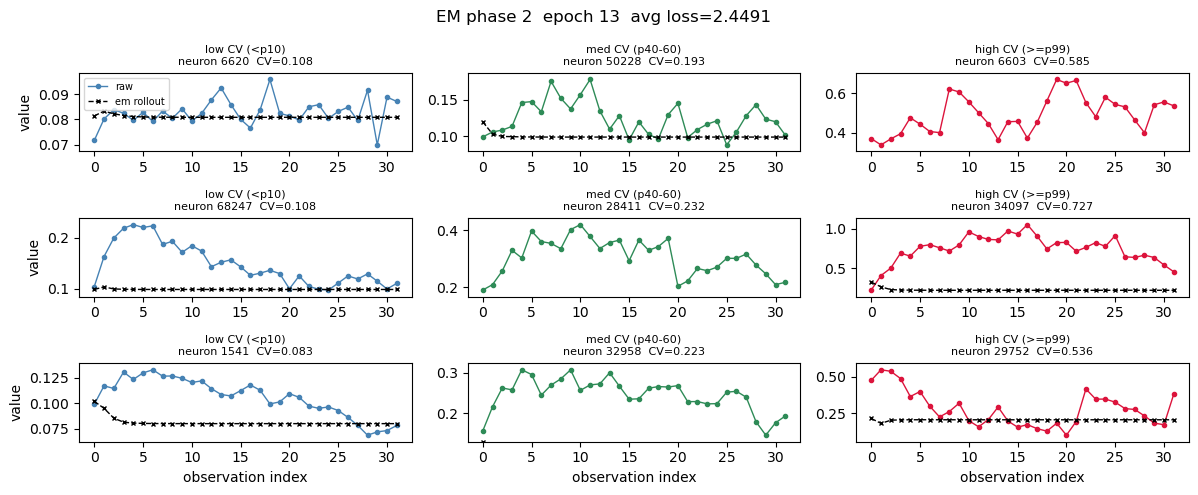

In [ ]:
# ── phase 2: EM-style training (Option B) ──────────────────────────────────
# E-step: infer z0 via pseudo-inverse, rollout with evolver
# M-step: update decoder and evolver on reconstruction loss

def infer_z0(w_vals, w_times, W_dec, b_dec):
    """infer z0 from observations at first time bin using pseudo-inverse.

    args:
        w_vals: (N, WINDOW) observed values
        w_times: (N, WINDOW) time bins for each observation
        W_dec: (N, L_DIM) decoder weights
        b_dec: (N,) decoder bias

    returns:
        z0: (L_DIM,) inferred initial latent state
        t_min: int, the first time bin
        T_window: int, number of time steps in window
        obs_idx: (N, WINDOW) indices into rollout for each observation
    """
    t_min = int(w_times.min().item())
    t_max = int(w_times.max().item())
    T_window = t_max - t_min + 1
    obs_idx = (w_times - t_min).long()  # (N, WINDOW)

    # find neurons with observations at t=0 (first time bin)
    mask_t0 = (obs_idx == 0)  # (N, WINDOW)
    neurons_at_t0 = mask_t0.any(dim=1)  # (N,)

    # get values at t=0 for those neurons
    obs_k_at_t0 = mask_t0.float().argmax(dim=1)  # which obs index is at t=0
    x_t0 = w_vals[neurons_at_t0, obs_k_at_t0[neurons_at_t0]]  # (M,)

    W_t0 = W_dec[neurons_at_t0]  # (M, L_DIM)
    b_t0 = b_dec[neurons_at_t0]  # (M,)

    # pseudo-inverse: z0 = lstsq(W, x - b)
    z0 = torch.linalg.lstsq(W_t0, (x_t0 - b_t0).unsqueeze(1)).solution.squeeze(1)

    return z0, t_min, T_window, obs_idx


def plot_em_rollout(k_start=0, title='', window=WINDOW):
    """plot EM-style rollout: infer z0, evolve, decode, compare to raw."""
    w_vals_p = obs_vals[:, k_start:k_start + window].to(device)
    w_times_p = obs_times[:, k_start:k_start + window].to(device)

    with torch.no_grad():
        z0, t_min, T_window, obs_idx = infer_z0(w_vals_p, w_times_p, W_dec, b_dec)
        z_traj = rollout(z0, T_window)  # (T_window, L_DIM)
        x_hat = decode(z_traj)  # (N, T_window)
        x_pred = x_hat[torch.arange(N, device=device).unsqueeze(1), obs_idx]  # (N, WINDOW)

    fig, axes = plt.subplots(N_PICK, 3, figsize=(12, 5), sharey=False)
    for col, (label, neurons, color) in enumerate([
        ('low CV (<p10)',   sample_low,  'steelblue'),
        ('med CV (p40-60)', sample_med,  'seagreen'),
        ('high CV (>=p99)', sample_high, 'crimson'),
    ]):
        for row, nid in enumerate(neurons):
            ax = axes[row, col]
            raw = w_vals_p[nid].cpu().numpy()
            pred = x_pred[nid].cpu().numpy()
            ax.plot(raw, color=color, marker='o', markersize=3, linewidth=1, label='raw')
            ax.plot(pred, color='black', marker='x', markersize=3, linewidth=1,
                    linestyle='--', label='em rollout')
            ymin, ymax = raw.min(), raw.max()
            margin = (ymax - ymin) * 0.1 or 0.1
            ax.set_ylim(ymin - margin, ymax + margin)
            ax.set_title(f'{label}\nneuron {nid.item()}  CV={neuron_cv[nid].item():.3f}', fontsize=8)
            if row == N_PICK - 1:
                ax.set_xlabel('observation index')
            if col == 0:
                ax.set_ylabel('value')
            if row == 0 and col == 0:
                ax.legend(fontsize=7)
    plt.suptitle(title or f'EM rollout (window k_start={k_start})')
    plt.tight_layout()
    plt.show()



num_windows_em = obs_vals.shape[1] // WINDOW_EM
em_losses = []

for epoch in range(N_PHASE2_EM_EPOCHS):
    epoch_losses = []

    # shuffle window order
    window_order = torch.randperm(num_windows_em)

    for w_idx in window_order:
        k_start = w_idx.item() * WINDOW_EM

        # get window data
        w_vals = obs_vals[:, k_start:k_start + WINDOW_EM].to(device)
        w_times = obs_times[:, k_start:k_start + WINDOW_EM].to(device)

        # check we have enough neurons at t=0
        t_min = int(w_times.min().item())
        obs_idx = (w_times - t_min).long()
        mask_t0 = (obs_idx == 0)
        n_neurons_t0 = mask_t0.any(dim=1).sum().item()

        if n_neurons_t0 < L_DIM:
            # not enough neurons to infer z0, skip
            continue

        # ── E-step: infer z0, rollout ──
        with torch.no_grad():
            z0, _, T_window, obs_idx = infer_z0(w_vals, w_times, W_dec, b_dec)

        # rollout with evolver (this is differentiable w.r.t. evolver)
        z_traj = rollout(z0.detach(), T_window)  # (T_window, L_DIM)

        # ── M-step: compute loss, update params ──
        x_hat = decode(z_traj)  # (N, T_window)
        x_pred = x_hat[torch.arange(N, device=device).unsqueeze(1), obs_idx]  # (N, WINDOW)

        # reconstruction loss (normalized by per-neuron std)
        std_w = w_vals.std(dim=1)
        valid = std_w > 1e-3
        if not valid.any():
            continue

        recon_loss = (((x_pred[valid] - w_vals[valid]) / std_w[valid].unsqueeze(1)) ** 2).mean()

        opt_em.zero_grad()
        recon_loss.backward()
        torch.nn.utils.clip_grad_norm_(list(evolver.parameters()) + [W_dec, b_dec], max_norm=1.0)
        opt_em.step()

        epoch_losses.append(recon_loss.item())
        em_losses.append(recon_loss.item())

    avg_loss = sum(epoch_losses) / max(len(epoch_losses), 1)

    clear_output(wait=True)
    print(f"  epoch {epoch+1}/{N_PHASE2_EM_EPOCHS}  avg loss={avg_loss:.4f}")
    plot_em_rollout(title=f'EM phase 2  epoch {epoch+1}  avg loss={avg_loss:.4f}')

print(f"phase 2 EM done  avg loss={sum(em_losses)/len(em_losses):.4f}")
plot_em_rollout(title=f'EM phase 2 final  avg loss={sum(em_losses)/len(em_losses):.4f}')

In [ ]:
plot_reconstruction()  # phase 1 quality (uses z_bank)
plot_em_rollout()      # phase 2 EM quality (infers z0, rolls out)

## Joint Training (Option A) - from scratch

In [85]:
# --- initialization for joint training (from scratch, SVD init) ---
L_DIM_JOINT = 64

# compute truncated SVD of full observation matrix (no centering)
print("computing truncated SVD for decoder initialization...")
X = obs_vals.to(device).float()  # (N, K)

# use torch.svd_lowrank for efficient truncated SVD
U, S, Vh = torch.svd_lowrank(X, q=L_DIM_JOINT)
print(f"  singular values: {S.cpu().tolist()[:10]}...")
print(f"  condition number (S[0]/S[-1]): {S[0]/S[-1]:.1f}")

# W_dec = top L_DIM left singular vectors (orthonormal)
W_dec_joint = nn.Parameter(U.contiguous())  # (N, L_DIM_JOINT)
b_dec_joint = nn.Parameter(torch.zeros(N, device=device))

print(f"  W_dec_joint: {W_dec_joint.shape}")
print(f"  orthonormal check: {torch.allclose(W_dec_joint.T @ W_dec_joint, torch.eye(L_DIM_JOINT, device=device), atol=1e-5)}")

# fresh evolver
evolver_joint = MLP(MLPParams(
    num_input_dims=L_DIM_JOINT,
    num_output_dims=L_DIM_JOINT,
    num_hidden_layers=1,
    num_hidden_units=L_DIM_JOINT,
    activation='Tanh',
    use_batch_norm=False,
)).to(device)

# init evolver to identity (zero output)
with torch.no_grad():
    last_linear = [m for m in evolver_joint.modules() if isinstance(m, nn.Linear)][-1]
    last_linear.weight.zero_()
    last_linear.bias.zero_()

print(f"joint training initialized: L_DIM={L_DIM_JOINT}")
print(f"  evolver_joint: {sum(p.numel() for p in evolver_joint.parameters())} params")

computing truncated SVD for decoder initialization...
  singular values: [2139.166748046875, 409.6823425292969, 316.2178649902344, 246.18524169921875, 200.7639617919922, 172.70181274414062, 158.2091827392578, 146.18910217285156, 143.07276916503906, 140.9678955078125]...
  condition number (S[0]/S[-1]): 48.9
  W_dec_joint: torch.Size([71721, 64])
  orthonormal check: False
joint training initialized: L_DIM=64
  evolver_joint: 8320 params


  epoch 15/50  avg loss=2.3237


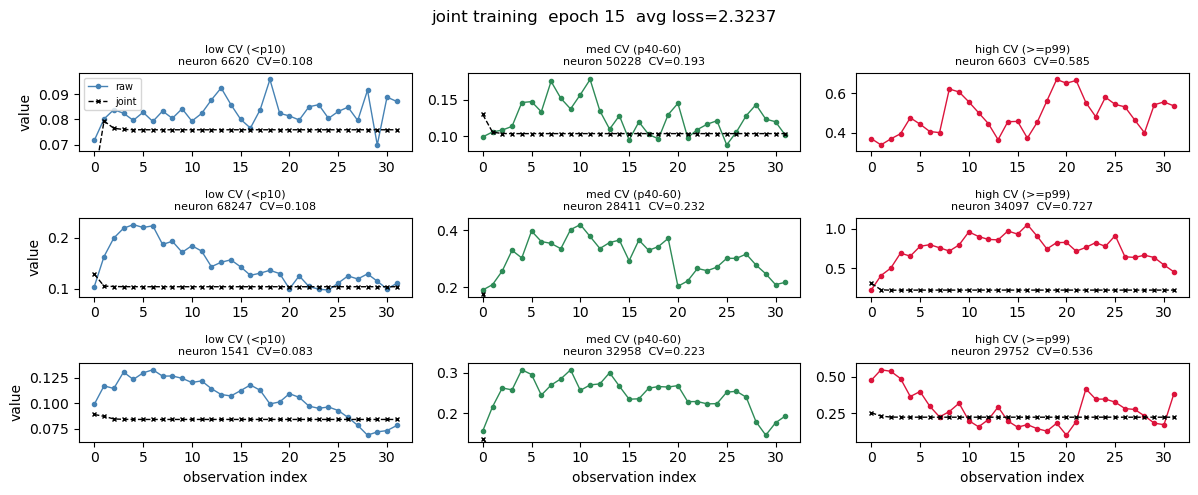

KeyboardInterrupt: 

In [87]:
# --- joint training loop ---

def rollout_joint(z0, T):
    """evolve z0 for T steps using evolver_joint."""
    zs = [None] * T
    zs[0] = z0
    z = z0
    for t in range(1, T):
        z = z + evolver_joint(z.unsqueeze(0)).squeeze(0)
        zs[t] = z
    return torch.stack(zs, dim=0)

def decode_joint(z):
    """linear decode using W_dec_joint, b_dec_joint."""
    return (z @ W_dec_joint.T + b_dec_joint).T

def infer_z0_joint(w_vals, w_times):
    """infer z0 using current W_dec_joint, b_dec_joint.

    since W_dec_joint is orthonormal, pseudo-inverse is just transpose:
    z = W^T @ (x - b)
    """
    t_min = int(w_times.min().item())
    t_max = int(w_times.max().item())
    T_window = t_max - t_min + 1
    obs_idx = (w_times - t_min).long()

    mask_t0 = (obs_idx == 0)
    neurons_at_t0 = mask_t0.any(dim=1)

    obs_k_at_t0 = mask_t0.float().argmax(dim=1)
    x_t0 = w_vals[neurons_at_t0, obs_k_at_t0[neurons_at_t0]]

    W_t0 = W_dec_joint[neurons_at_t0]
    b_t0 = b_dec_joint[neurons_at_t0]

    # for orthonormal W, pseudo-inverse is transpose
    # but we only have a subset of neurons, so still use lstsq
    z0 = torch.linalg.lstsq(W_t0, (x_t0 - b_t0).unsqueeze(1)).solution.squeeze(1)

    return z0, T_window, obs_idx

def plot_joint_rollout(k_start=0, title='', window=WINDOW):
    """plot joint training rollout."""
    w_vals_p = obs_vals[:, k_start:k_start + window].to(device)
    w_times_p = obs_times[:, k_start:k_start + window].to(device)

    with torch.no_grad():
        z0, T_window, obs_idx = infer_z0_joint(w_vals_p, w_times_p)
        z_traj = rollout_joint(z0, T_window)
        x_hat = decode_joint(z_traj)
        x_pred = x_hat[torch.arange(N, device=device).unsqueeze(1), obs_idx]

    fig, axes = plt.subplots(N_PICK, 3, figsize=(12, 5), sharey=False)
    for col, (label, neurons, color) in enumerate([
        ('low CV (<p10)',   sample_low,  'steelblue'),
        ('med CV (p40-60)', sample_med,  'seagreen'),
        ('high CV (>=p99)', sample_high, 'crimson'),
    ]):
        for row, nid in enumerate(neurons):
            ax = axes[row, col]
            raw = w_vals_p[nid].cpu().numpy()
            pred = x_pred[nid].cpu().numpy()
            ax.plot(raw, color=color, marker='o', markersize=3, linewidth=1, label='raw')
            ax.plot(pred, color='black', marker='x', markersize=3, linewidth=1,
                    linestyle='--', label='joint')
            ymin, ymax = raw.min(), raw.max()
            margin = (ymax - ymin) * 0.1 or 0.1
            ax.set_ylim(ymin - margin, ymax + margin)
            ax.set_title(f'{label}\nneuron {nid.item()}  CV={neuron_cv[nid].item():.3f}', fontsize=8)
            if row == N_PICK - 1:
                ax.set_xlabel('observation index')
            if col == 0:
                ax.set_ylabel('value')
            if row == 0 and col == 0:
                ax.legend(fontsize=7)
    plt.suptitle(title or f'joint rollout (k_start={k_start})')
    plt.tight_layout()
    plt.show()


# --- training ---
print("joint training: decoder + evolver (SVD init)")
LR_JOINT = 1e-3
N_JOINT_EPOCHS = 50
WINDOW_JOINT = WINDOW

opt_joint = torch.optim.Adam(
    [W_dec_joint, b_dec_joint] + list(evolver_joint.parameters()),
    lr=LR_JOINT
)

num_windows_joint = obs_vals.shape[1] // WINDOW_JOINT
joint_losses = []

for epoch in range(N_JOINT_EPOCHS):
    epoch_losses = []

    window_order = torch.randperm(num_windows_joint)

    for w_idx in window_order:
        k_start = w_idx.item() * WINDOW_JOINT

        w_vals = obs_vals[:, k_start:k_start + WINDOW_JOINT].to(device)
        w_times = obs_times[:, k_start:k_start + WINDOW_JOINT].to(device)

        # check enough neurons at t=0
        t_min = int(w_times.min().item())
        obs_idx = (w_times - t_min).long()
        mask_t0 = (obs_idx == 0)
        n_neurons_t0 = mask_t0.any(dim=1).sum().item()

        if n_neurons_t0 < L_DIM_JOINT:
            continue

        # E-step: infer z0
        with torch.no_grad():
            z0, T_window, obs_idx = infer_z0_joint(w_vals, w_times)

        # rollout (differentiable w.r.t. evolver)
        z_traj = rollout_joint(z0.detach(), T_window)

        # decode and compute loss
        x_hat = decode_joint(z_traj)
        x_pred = x_hat[torch.arange(N, device=device).unsqueeze(1), obs_idx]

        # normalized reconstruction loss
        std_w = w_vals.std(dim=1)
        valid = std_w > 1e-3
        if not valid.any():
            continue

        recon_loss = (((x_pred[valid] - w_vals[valid]) / std_w[valid].unsqueeze(1)) ** 2).mean()

        opt_joint.zero_grad()
        recon_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(evolver_joint.parameters()) + [W_dec_joint, b_dec_joint],
            max_norm=1.0
        )
        opt_joint.step()

        epoch_losses.append(recon_loss.item())
        joint_losses.append(recon_loss.item())

    avg_loss = sum(epoch_losses) / max(len(epoch_losses), 1)

    clear_output(wait=True)
    print(f"  epoch {epoch+1}/{N_JOINT_EPOCHS}  avg loss={avg_loss:.4f}")
    plot_joint_rollout(title=f'joint training  epoch {epoch+1}  avg loss={avg_loss:.4f}')

print(f"joint training done  avg loss={sum(joint_losses)/len(joint_losses):.4f}")
plot_joint_rollout(title=f'joint training final  avg loss={sum(joint_losses[-num_windows_joint:])/num_windows_joint:.4f}')

## Direct Z Inference at Every Time Step

In [11]:
# --- initialization for direct z inference approach ---
L_DIM_DIRECT = 64

# compute truncated SVD of full observation matrix (no centering)
print("computing truncated SVD for decoder initialization...")
X = obs_vals.to(device).float()  # (N, K)

U, S, Vh = torch.svd_lowrank(X, q=L_DIM_DIRECT)
print(f"  singular values (top 10): {S[:10].cpu().tolist()}")
print(f"  condition number (S[0]/S[-1]): {S[0]/S[-1]:.1f}")

# W_dec = top L_DIM left singular vectors (orthonormal)
W_dec_direct = nn.Parameter(U.contiguous())  # (N, L_DIM)
b_dec_direct = nn.Parameter(torch.zeros(N, device=device))

print(f"  W_dec_direct: {W_dec_direct.shape}")

# fresh evolver
evolver_direct = MLP(MLPParams(
    num_input_dims=L_DIM_DIRECT,
    num_output_dims=L_DIM_DIRECT,
    num_hidden_layers=1,
    num_hidden_units=L_DIM_DIRECT,
    activation='Tanh',
    use_batch_norm=False,
)).to(device)

# init evolver to identity (zero output)
with torch.no_grad():
    last_linear = [m for m in evolver_direct.modules() if isinstance(m, nn.Linear)][-1]
    last_linear.weight.zero_()
    last_linear.bias.zero_()

print(f"direct z inference initialized: L_DIM={L_DIM_DIRECT}")

computing truncated SVD for decoder initialization...
  singular values (top 10): [2139.1630859375, 409.6832275390625, 316.21728515625, 246.18617248535156, 200.76446533203125, 172.7009735107422, 158.2088165283203, 146.19032287597656, 143.072265625, 140.96914672851562]
  condition number (S[0]/S[-1]): 49.7
  W_dec_direct: torch.Size([71721, 64])
direct z inference initialized: L_DIM=64


  epoch 4/50  evolver_loss=125.3731


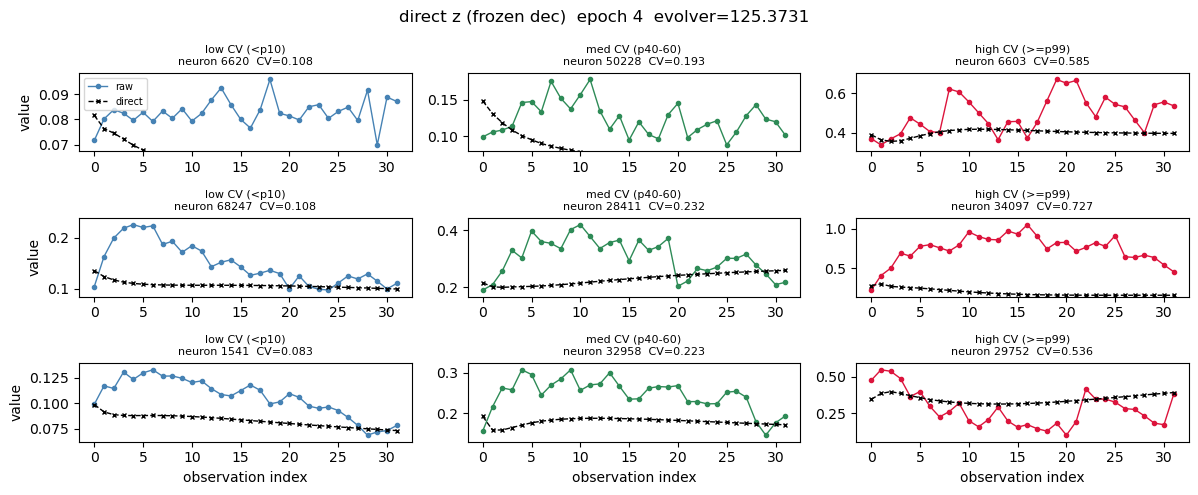

KeyboardInterrupt: 

In [12]:
# --- direct z inference training loop (Option B: frozen decoder) ---

def infer_z_at_time(t, w_vals, w_times, W_dec, b_dec):
    """infer z at time bin t from neurons observed at that time.

    returns z (L_DIM,) or None if not enough neurons observed.
    """
    # find observations at time t
    mask_t = (w_times == t)  # (N, WINDOW)
    neurons_at_t = mask_t.any(dim=1)  # (N,)
    n_neurons = neurons_at_t.sum().item()

    if n_neurons < W_dec.shape[1]:  # need at least L_DIM neurons
        return None

    # get values at time t for observed neurons
    obs_k_at_t = mask_t.float().argmax(dim=1)  # which obs index
    x_t = w_vals[neurons_at_t, obs_k_at_t[neurons_at_t]]  # (M,)

    W_t = W_dec[neurons_at_t]  # (M, L)
    b_t = b_dec[neurons_at_t]  # (M,)

    z_t = torch.linalg.lstsq(W_t, (x_t - b_t).unsqueeze(1)).solution.squeeze(1)
    return z_t


def infer_z_trajectory(w_vals, w_times, W_dec, b_dec):
    """infer z at all time bins in window.

    returns:
        z_traj: dict mapping time_bin -> z vector
        time_bins: sorted list of time bins with valid z
    """
    t_min = int(w_times.min().item())
    t_max = int(w_times.max().item())

    z_traj = {}
    for t in range(t_min, t_max + 1):
        z_t = infer_z_at_time(t, w_vals, w_times, W_dec, b_dec)
        if z_t is not None:
            z_traj[t] = z_t

    time_bins = sorted(z_traj.keys())
    return z_traj, time_bins


def rollout_direct(z0, T):
    """evolve z0 for T steps using evolver_direct."""
    zs = [None] * T
    zs[0] = z0
    z = z0
    for t in range(1, T):
        z = z + evolver_direct(z.unsqueeze(0)).squeeze(0)
        zs[t] = z
    return torch.stack(zs, dim=0)


def decode_direct(z):
    """linear decode using W_dec_direct, b_dec_direct."""
    return (z @ W_dec_direct.T + b_dec_direct).T


def plot_direct_rollout(k_start=0, title='', window=WINDOW):
    """plot direct z inference approach."""
    w_vals_p = obs_vals[:, k_start:k_start + window].to(device)
    w_times_p = obs_times[:, k_start:k_start + window].to(device)

    with torch.no_grad():
        z_traj, time_bins = infer_z_trajectory(w_vals_p, w_times_p, W_dec_direct, b_dec_direct)
        if len(time_bins) < 2:
            print("not enough time bins with observations")
            return

        # rollout from first z
        t0 = time_bins[0]
        t_end = time_bins[-1]
        T_window = t_end - t0 + 1
        z_rolled = rollout_direct(z_traj[t0], T_window)
        x_hat = decode_direct(z_rolled)

        # gather predictions at observation times (clamp to valid range)
        obs_idx = (w_times_p - t0).long().clamp(0, T_window - 1)
        x_pred = x_hat[torch.arange(N, device=device).unsqueeze(1), obs_idx]

    fig, axes = plt.subplots(N_PICK, 3, figsize=(12, 5), sharey=False)
    for col, (label, neurons, color) in enumerate([
        ('low CV (<p10)',   sample_low,  'steelblue'),
        ('med CV (p40-60)', sample_med,  'seagreen'),
        ('high CV (>=p99)', sample_high, 'crimson'),
    ]):
        for row, nid in enumerate(neurons):
            ax = axes[row, col]
            raw = w_vals_p[nid].cpu().numpy()
            pred = x_pred[nid].cpu().numpy()
            ax.plot(raw, color=color, marker='o', markersize=3, linewidth=1, label='raw')
            ax.plot(pred, color='black', marker='x', markersize=3, linewidth=1,
                    linestyle='--', label='direct')
            ymin, ymax = raw.min(), raw.max()
            margin = (ymax - ymin) * 0.1 or 0.1
            ax.set_ylim(ymin - margin, ymax + margin)
            ax.set_title(f'{label}\nneuron {nid.item()}  CV={neuron_cv[nid].item():.3f}', fontsize=8)
            if row == N_PICK - 1:
                ax.set_xlabel('observation index')
            if col == 0:
                ax.set_ylabel('value')
            if row == 0 and col == 0:
                ax.legend(fontsize=7)
    plt.suptitle(title or f'direct z rollout (k_start={k_start})')
    plt.tight_layout()
    plt.show()


# --- training (Option B: frozen decoder, only train evolver) ---
print("direct z inference training: frozen decoder, evolver learns z transitions")
LR_DIRECT = 1e-3
N_DIRECT_EPOCHS = 50
WINDOW_DIRECT = WINDOW

# only train evolver - decoder is frozen at SVD initialization
opt_direct = torch.optim.Adam(
    list(evolver_direct.parameters()),
    lr=LR_DIRECT
)

num_windows_direct = obs_vals.shape[1] // WINDOW_DIRECT
direct_losses = []

for epoch in range(N_DIRECT_EPOCHS):
    epoch_evolver_losses = []

    window_order = torch.randperm(num_windows_direct)

    for w_idx in window_order:
        k_start = w_idx.item() * WINDOW_DIRECT

        w_vals = obs_vals[:, k_start:k_start + WINDOW_DIRECT].to(device)
        w_times = obs_times[:, k_start:k_start + WINDOW_DIRECT].to(device)

        # infer z at all time points using frozen decoder
        with torch.no_grad():
            z_traj, time_bins = infer_z_trajectory(w_vals, w_times, W_dec_direct, b_dec_direct)

        if len(time_bins) < 2:
            continue

        # stack z values for consecutive time bins
        z_list = [z_traj[t] for t in time_bins]
        z_stack = torch.stack(z_list, dim=0)  # (T, L_DIM)

        # evolver loss: predict z_{t+1} from z_t
        z_curr = z_stack[:-1]  # (T-1, L_DIM)
        z_next_target = z_stack[1:]  # (T-1, L_DIM)

        # handle non-consecutive time bins: only train on consecutive pairs
        time_diffs = torch.tensor([time_bins[i+1] - time_bins[i] for i in range(len(time_bins)-1)], device=device)
        consecutive_mask = (time_diffs == 1)

        if not consecutive_mask.any():
            continue

        z_curr_consec = z_curr[consecutive_mask]
        z_next_target_consec = z_next_target[consecutive_mask]

        # evolver prediction: z_{t+1} = z_t + evolver(z_t)
        z_next_pred = z_curr_consec + evolver_direct(z_curr_consec)
        evolver_loss = F.mse_loss(z_next_pred, z_next_target_consec)

        opt_direct.zero_grad()
        evolver_loss.backward()
        torch.nn.utils.clip_grad_norm_(evolver_direct.parameters(), max_norm=1.0)
        opt_direct.step()

        epoch_evolver_losses.append(evolver_loss.item())
        direct_losses.append(evolver_loss.item())

    avg_evolver = sum(epoch_evolver_losses) / max(len(epoch_evolver_losses), 1)

    clear_output(wait=True)
    print(f"  epoch {epoch+1}/{N_DIRECT_EPOCHS}  evolver_loss={avg_evolver:.4f}")
    plot_direct_rollout(title=f'direct z (frozen dec)  epoch {epoch+1}  evolver={avg_evolver:.4f}')

print(f"direct z training done  final evolver_loss={sum(direct_losses[-num_windows_direct:])/num_windows_direct:.4f}")
plot_direct_rollout(title=f'direct z final (frozen decoder)')

## Learn decoder via Alternating Least Squares (ALS)

In [63]:
# learn W_dec, b_dec via gradient descent on lstsq reconstruction
#
# for each batch of time bins:
#   1. infer z = lstsq(W, x - b)  [differentiable]
#   2. decode x_hat = W @ z + b
#   3. loss = MSE(x_hat, x)
#   4. backprop

L_DIM_LEARN = 64
LR_LEARN = 1e-3

BATCH_SIZE = 64  # time bins per batch

# move data to GPU
obs_times_gpu = obs_times.to(device)
obs_vals_gpu = obs_vals.to(device)

T_total = int(obs_times.max().item()) + 1
K = obs_times_gpu.shape[1]
print(f"learning decoder: N={N}, T={T_total}, L_DIM={L_DIM_LEARN}")

# initialize
W_learn = nn.Parameter(torch.randn(N, L_DIM_LEARN, device=device) * 0.01)
b_learn = nn.Parameter(torch.zeros(N, device=device))

opt_learn = torch.optim.Adam([W_learn, b_learn], lr=LR_LEARN)

# precompute valid time bins (>= L_DIM neurons) using bincount
flat_times = obs_times_gpu.flatten().long()
neurons_per_time = torch.bincount(flat_times, minlength=T_total)
valid_times = torch.where(neurons_per_time >= L_DIM_LEARN)[0]
valid_times_mask = neurons_per_time >= L_DIM_LEARN
print(f"valid time bins: {len(valid_times)} / {T_total}")

# precompute neuron indices and values for each valid time
# use sorted structure for fast lookup
print("building time index...")
neuron_idx = torch.arange(N, device=device).unsqueeze(1).expand(N, K).flatten()
flat_vals = obs_vals_gpu.flatten()

sort_idx = flat_times.argsort()
sorted_times = flat_times[sort_idx]
sorted_neurons = neuron_idx[sort_idx]
sorted_vals = flat_vals[sort_idx]

unique_times, counts = torch.unique_consecutive(sorted_times, return_counts=True)
boundaries = torch.cat([torch.zeros(1, device=device, dtype=torch.long), counts.cumsum(0)])

# map from time -> index in unique_times
time_to_idx = torch.full((T_total,), -1, dtype=torch.long, device=device)
time_to_idx[unique_times] = torch.arange(len(unique_times), device=device)

print("ready to train")

learning decoder: N=71721, T=37838, L_DIM=64
valid time bins: 35189 / 37838
building time index...
ready to train


epoch 20/20  recon=0.006627  smooth=0.0281


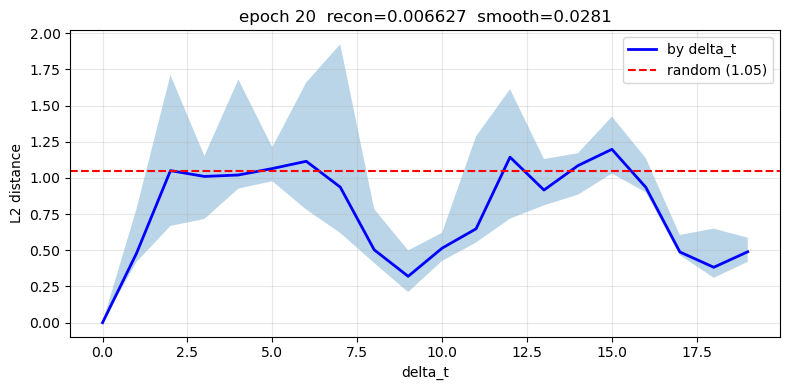


training done. final recon: 0.006627, smooth: 0.0281


In [66]:
# training loop with temporal smoothness loss

N_EPOCHS = 20
SMOOTH_WEIGHT = 10.0

def get_time_data(t):
    """get neuron indices and values for time bin t."""
    idx = time_to_idx[t].item()
    start = boundaries[idx].item()
    end = boundaries[idx + 1].item()
    return sorted_neurons[start:end], sorted_vals[start:end]

def compute_z(t):
    """compute z for a single time bin."""
    neuron_indices, x_t = get_time_data(t)
    W_t = W_learn[neuron_indices]
    b_t = b_learn[neuron_indices]
    z_t = torch.linalg.lstsq(W_t, (x_t - b_t).unsqueeze(1)).solution.squeeze(1)
    return z_t

def compute_z_and_loss(t):
    """compute z via lstsq and reconstruction loss for time bin t."""
    neuron_indices, x_t = get_time_data(t)
    W_t = W_learn[neuron_indices]
    b_t = b_learn[neuron_indices]
    z_t = torch.linalg.lstsq(W_t, (x_t - b_t).unsqueeze(1)).solution.squeeze(1)
    x_hat = W_t @ z_t + b_t
    recon_loss = F.mse_loss(x_hat, x_t)
    return z_t, recon_loss

def compute_z_batch(times):
    """compute z for a batch of times, return (T, L_DIM) tensor."""
    zs = []
    for t in times:
        zs.append(compute_z(t))
    return torch.stack(zs)

def plot_latent_distance_vs_delta(max_delta=20, pairs_per_delta=10, n_random=100):
    """compute latent distance vs time separation (samples z on-demand)."""
    valid_time_idx = torch.where(valid_times_mask)[0]

    delta_ts = []
    distances = []

    with torch.no_grad():
        for delta_t in range(max_delta):
            valid_starts = valid_time_idx[valid_time_idx + delta_t < T_total]
            t_plus_valid = valid_times_mask[valid_starts + delta_t]
            valid_pairs_dt = valid_starts[t_plus_valid]

            if len(valid_pairs_dt) < pairs_per_delta:
                continue

            perm = torch.randperm(len(valid_pairs_dt), device=device)[:pairs_per_delta]
            sampled_t = valid_pairs_dt[perm]

            z_t = compute_z_batch(sampled_t.tolist())
            z_t_delta = compute_z_batch((sampled_t + delta_t).tolist())
            dists = torch.norm(z_t_delta - z_t, dim=1)

            delta_ts.extend([delta_t] * len(dists))
            distances.extend(dists.tolist())

        # random baseline: sample random pairs of valid times
        perm1 = torch.randperm(len(valid_time_idx), device=device)[:n_random]
        perm2 = torch.randperm(len(valid_time_idx), device=device)[:n_random]
        t1 = valid_time_idx[perm1]
        t2 = valid_time_idx[perm2]
        z1 = compute_z_batch(t1.tolist())
        z2 = compute_z_batch(t2.tolist())
        random_dists = torch.norm(z2 - z1, dim=1)
        random_median = random_dists.median().item()

    delta_ts = np.array(delta_ts)
    distances = np.array(distances)

    unique_deltas = np.unique(delta_ts)
    medians = np.array([np.median(distances[delta_ts == dt]) for dt in unique_deltas])
    q25s = np.array([np.percentile(distances[delta_ts == dt], 25) for dt in unique_deltas])
    q75s = np.array([np.percentile(distances[delta_ts == dt], 75) for dt in unique_deltas])

    return unique_deltas, medians, q25s, q75s, random_median

# find valid time pairs
valid_times_set = set(valid_times.tolist())
valid_pairs = torch.tensor([t for t in valid_times.tolist() if (t + 1) in valid_times_set], device=device)
print(f"valid time pairs (t, t+1): {len(valid_pairs)}")

learn_losses = []
recon_losses_hist = []
smooth_losses_hist = []
# num_batches = len(valid_pairs) // BATCH_SIZE
num_batches = 10
for epoch in range(N_EPOCHS):
    perm = torch.randperm(len(valid_pairs), device=device)
    shuffled_pairs = valid_pairs[perm]

    epoch_recon = []
    epoch_smooth = []

    for batch_idx in tqdm(range(num_batches), desc=f"epoch {epoch+1}", leave=False):
        batch_t = shuffled_pairs[batch_idx * BATCH_SIZE : (batch_idx + 1) * BATCH_SIZE]

        recon_loss = 0.0
        z_list = []
        z_next_list = []

        for t in batch_t:
            t = t.item()
            z_t, loss_t = compute_z_and_loss(t)
            z_t1, loss_t1 = compute_z_and_loss(t + 1)
            recon_loss = recon_loss + loss_t + loss_t1
            z_list.append(z_t)
            z_next_list.append(z_t1)

        z_stack = torch.stack(z_list)
        z_next_stack = torch.stack(z_next_list)
        smooth_loss = F.mse_loss(z_stack, z_next_stack)

        recon_loss = recon_loss / (2 * BATCH_SIZE)
        total_loss = recon_loss + SMOOTH_WEIGHT * smooth_loss

        opt_learn.zero_grad()
        total_loss.backward()
        opt_learn.step()

        epoch_recon.append(recon_loss.item())
        epoch_smooth.append(smooth_loss.item())

    avg_recon = np.mean(epoch_recon)
    avg_smooth = np.mean(epoch_smooth)
    learn_losses.append(avg_recon + SMOOTH_WEIGHT * avg_smooth)
    recon_losses_hist.append(avg_recon)
    smooth_losses_hist.append(avg_smooth)

    # plots (compute z on-demand for sampled points only)
    clear_output(wait=True)
    print(f"epoch {epoch+1}/{N_EPOCHS}  recon={avg_recon:.6f}  smooth={avg_smooth:.4f}")

    fig, ax = plt.subplots(figsize=(8, 4))
    unique_deltas, medians, q25s, q75s, random_med = plot_latent_distance_vs_delta()
    ax.fill_between(unique_deltas, q25s, q75s, alpha=0.3)
    ax.plot(unique_deltas, medians, 'b-', linewidth=2, label='by delta_t')
    ax.axhline(random_med, color='r', linestyle='--', label=f'random ({random_med:.2f})')
    ax.set_xlabel('delta_t')
    ax.set_ylabel('L2 distance')
    ax.set_title(f'epoch {epoch+1}  recon={avg_recon:.6f}  smooth={avg_smooth:.4f}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print(f"\ntraining done. final recon: {recon_losses_hist[-1]:.6f}, smooth: {smooth_losses_hist[-1]:.4f}")

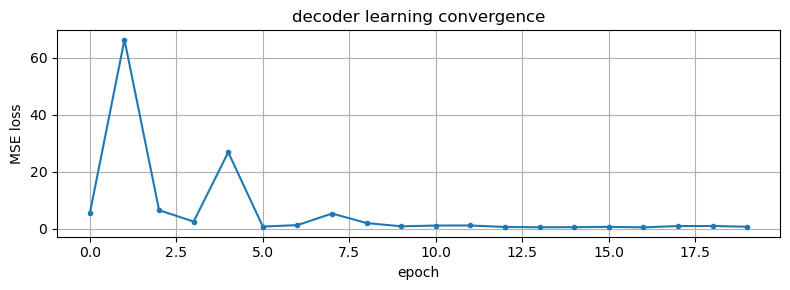

computing z for all valid times...


inferring z:   0%|          | 0/35189 [00:00<?, ?it/s]

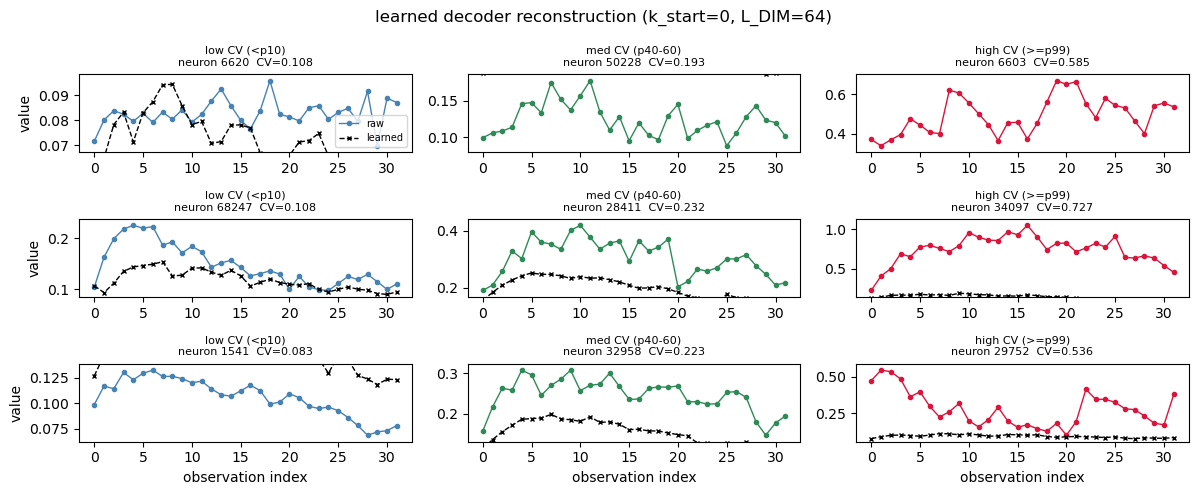

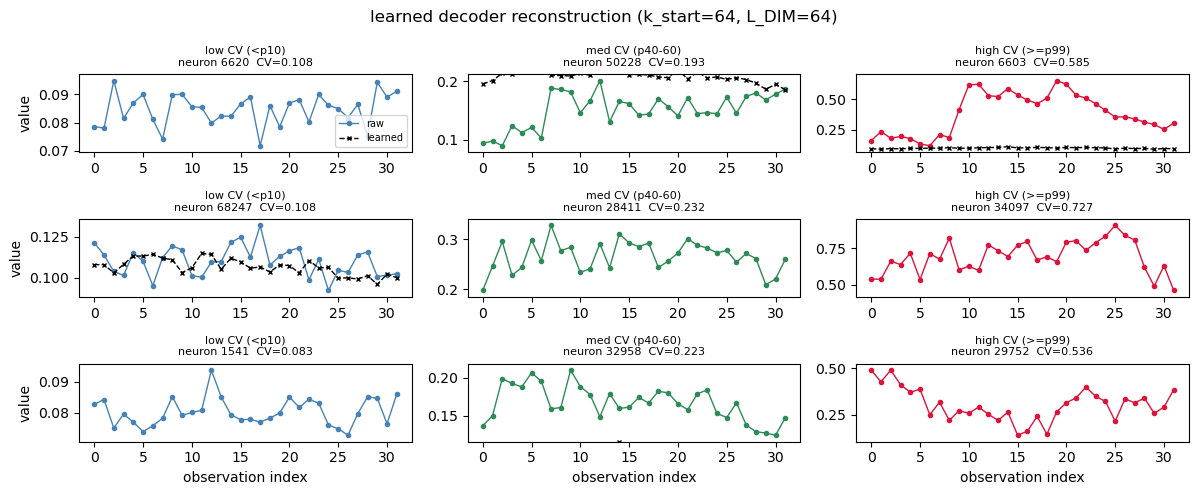

In [65]:
# plot loss curve and reconstruction

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(learn_losses, marker='o', markersize=3)
ax.set_xlabel('epoch')
ax.set_ylabel('MSE loss')
ax.set_title('decoder learning convergence')
ax.grid(True)
plt.tight_layout()
plt.show()

# compute z for all valid times for plotting
print("computing z for all valid times...")
z_learn = torch.zeros(T_total, L_DIM_LEARN, device=device)
valid_times_mask = torch.zeros(T_total, dtype=torch.bool, device=device)

with torch.no_grad():
    for t in tqdm(valid_times.tolist(), desc="inferring z"):
        neuron_indices, x_t = get_time_data(t)
        W_t = W_learn[neuron_indices]
        b_t = b_learn[neuron_indices]
        z_t = torch.linalg.lstsq(W_t, (x_t - b_t).unsqueeze(1)).solution.squeeze(1)
        z_learn[t] = z_t
        valid_times_mask[t] = True

# plot reconstruction
def plot_learn_reconstruction(k_start=0, window=WINDOW):
    """plot learned decoder reconstruction."""
    w_vals_p = obs_vals_gpu[:, k_start:k_start + window]
    w_times_p = obs_times_gpu[:, k_start:k_start + window].long()

    z_at_obs = z_learn[w_times_p]
    x_recon = (z_at_obs * W_learn.unsqueeze(1)).sum(-1) + b_learn.unsqueeze(1)
    valid_mask = valid_times_mask[w_times_p]

    fig, axes = plt.subplots(N_PICK, 3, figsize=(12, 5), sharey=False)
    for col, (label, neurons, color) in enumerate([
        ('low CV (<p10)',   sample_low,  'steelblue'),
        ('med CV (p40-60)', sample_med,  'seagreen'),
        ('high CV (>=p99)', sample_high, 'crimson'),
    ]):
        for row, nid in enumerate(neurons):
            ax = axes[row, col]
            raw = w_vals_p[nid].cpu().numpy()
            recon = x_recon[nid].detach().cpu().numpy()
            mask = valid_mask[nid].cpu().numpy()

            ax.plot(raw, color=color, marker='o', markersize=3, linewidth=1, label='raw')
            recon_masked = np.where(mask, recon, np.nan)
            ax.plot(recon_masked, color='black', marker='x', markersize=3, linewidth=1,
                    linestyle='--', label='learned')

            ymin, ymax = raw.min(), raw.max()
            margin = (ymax - ymin) * 0.1 or 0.1
            ax.set_ylim(ymin - margin, ymax + margin)
            ax.set_title(f'{label}\nneuron {nid.item()}  CV={neuron_cv[nid].item():.3f}', fontsize=8)
            if row == N_PICK - 1:
                ax.set_xlabel('observation index')
            if col == 0:
                ax.set_ylabel('value')
            if row == 0 and col == 0:
                ax.legend(fontsize=7)

    plt.suptitle(f'learned decoder reconstruction (k_start={k_start}, L_DIM={L_DIM_LEARN})')
    plt.tight_layout()
    plt.show()

plot_learn_reconstruction(k_start=0)
plot_learn_reconstruction(k_start=64)

sampling:   0%|          | 0/10000 [00:00<?, ?it/s]

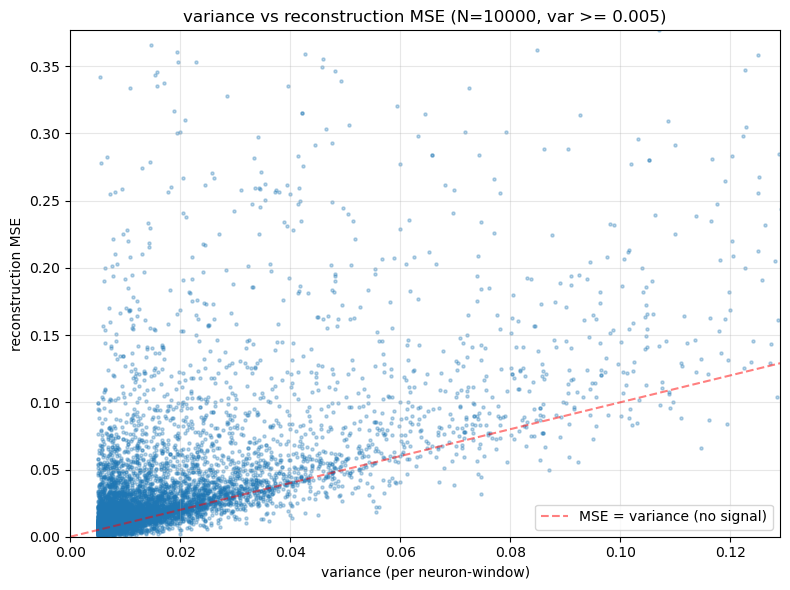

correlation: 0.589
mean variance: 0.018145, mean MSE: 0.037405
mean MSE / mean variance: 2.061


In [52]:
# scatter plot: variance vs reconstruction MSE per (neuron, 32-frame window)
# discard low-variance samples

N_SAMPLES = 10_000
WINDOW_SIZE = 32
MIN_VARIANCE = 0.005

num_windows = obs_vals_gpu.shape[1] // WINDOW_SIZE

# sample until we get N_SAMPLES with variance >= MIN_VARIANCE
torch.manual_seed(42)
variances = []
mses = []

with torch.no_grad():
    pbar = tqdm(total=N_SAMPLES, desc="sampling")
    while len(variances) < N_SAMPLES:
        # sample a batch
        batch_size = min(1000, N_SAMPLES - len(variances) + 500)
        sample_neurons = torch.randint(0, N, (batch_size,), device=device)
        sample_windows = torch.randint(0, num_windows, (batch_size,), device=device)

        for i in range(batch_size):
            if len(variances) >= N_SAMPLES:
                break

            n = sample_neurons[i].item()
            w = sample_windows[i].item()
            k_start = w * WINDOW_SIZE

            # get raw values for this (neuron, window)
            raw_vals = obs_vals_gpu[n, k_start:k_start + WINDOW_SIZE]
            variance = raw_vals.var().item()

            # skip low variance
            if variance < MIN_VARIANCE:
                continue

            # get reconstruction: z at observation times, decode
            times_w = obs_times_gpu[n, k_start:k_start + WINDOW_SIZE].long()
            z_at_obs = z_learn[times_w]  # (WINDOW_SIZE, L_DIM)
            recon = (z_at_obs * W_learn[n]).sum(-1) + b_learn[n]  # (WINDOW_SIZE,)

            mse = F.mse_loss(recon, raw_vals).item()

            variances.append(variance)
            mses.append(mse)
            pbar.update(1)
    pbar.close()

variances = np.array(variances)
mses = np.array(mses)

# plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(variances, mses, alpha=0.3, s=5)
ax.set_xlabel('variance (per neuron-window)')
ax.set_ylabel('reconstruction MSE')
ax.set_title(f'variance vs reconstruction MSE (N={N_SAMPLES}, var >= {MIN_VARIANCE})')

# add diagonal line (MSE = variance means no signal captured)
max_val = max(variances.max(), mses.max())
ax.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='MSE = variance (no signal)')
ax.legend()

ax.set_xlim(0, np.percentile(variances, 99))
ax.set_ylim(0, np.percentile(mses, 99))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# stats
corr = np.corrcoef(variances, mses)[0, 1]
print(f"correlation: {corr:.3f}")
print(f"mean variance: {variances.mean():.6f}, mean MSE: {mses.mean():.6f}")
print(f"mean MSE / mean variance: {mses.mean() / variances.mean():.3f}")

valid time bins: 35189


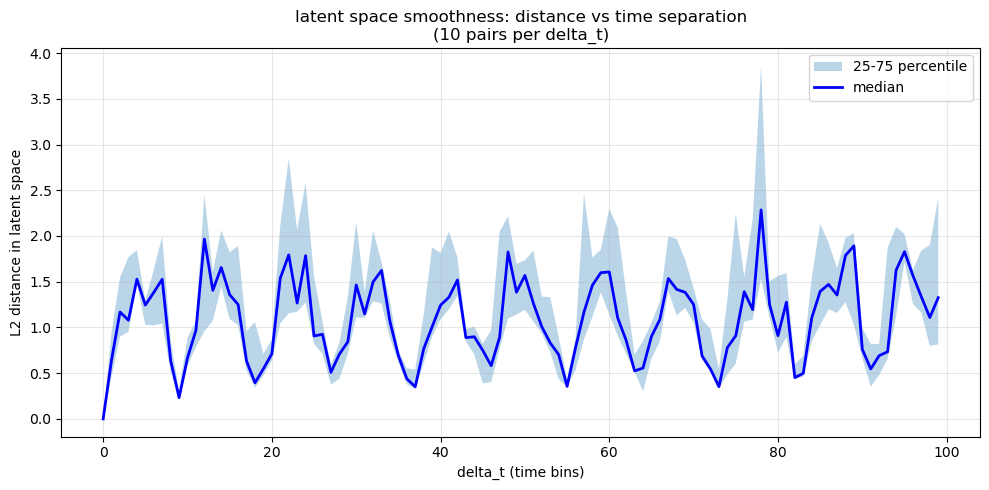

random pairs baseline: median=1.3781


In [54]:
# analyze latent space smoothness: distance vs delta_t (vectorized)

MAX_DELTA_T = 100
PAIRS_PER_DELTA = 10

# get valid time indices
valid_time_indices = torch.where(valid_times_mask)[0]
print(f"valid time bins: {len(valid_time_indices)}")

torch.manual_seed(123)

delta_ts = []
distances = []

with torch.no_grad():
    for delta_t in range(MAX_DELTA_T):
        # vectorized: find valid starts where t+delta_t is also valid
        valid_starts = valid_time_indices[valid_time_indices + delta_t < T_total]
        # check t+delta_t validity using indexing
        t_plus_delta_valid = valid_times_mask[valid_starts + delta_t]
        valid_pairs = valid_starts[t_plus_delta_valid]

        if len(valid_pairs) < PAIRS_PER_DELTA:
            continue

        # sample random pairs
        perm = torch.randperm(len(valid_pairs), device=device)[:PAIRS_PER_DELTA]
        sampled_t = valid_pairs[perm]

        # compute distances in batch
        z_t = z_learn[sampled_t]
        z_t_delta = z_learn[sampled_t + delta_t]
        dists = torch.norm(z_t_delta - z_t, dim=1)

        for d in dists:
            delta_ts.append(delta_t)
            distances.append(d.item())

delta_ts = np.array(delta_ts)
distances = np.array(distances)

# compute median and quartiles per delta_t
unique_deltas = np.unique(delta_ts)
medians = []
q25s = []
q75s = []

for dt in unique_deltas:
    mask = delta_ts == dt
    dists = distances[mask]
    medians.append(np.median(dists))
    q25s.append(np.percentile(dists, 25))
    q75s.append(np.percentile(dists, 75))

medians = np.array(medians)
q25s = np.array(q25s)
q75s = np.array(q75s)

# plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(unique_deltas, q25s, q75s, alpha=0.3, label='25-75 percentile')
ax.plot(unique_deltas, medians, 'b-', linewidth=2, label='median')
ax.set_xlabel('delta_t (time bins)')
ax.set_ylabel('L2 distance in latent space')
ax.set_title(f'latent space smoothness: distance vs time separation\n({PAIRS_PER_DELTA} pairs per delta_t)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# baseline: random pairs
n_random = 1000
random_t1 = valid_time_indices[torch.randperm(len(valid_time_indices), device=device)[:n_random]]
random_t2 = valid_time_indices[torch.randperm(len(valid_time_indices), device=device)[:n_random]]
random_dists = torch.norm(z_learn[random_t1] - z_learn[random_t2], dim=1).cpu().numpy()
print(f"random pairs baseline: median={np.median(random_dists):.4f}")
